# Imports

In [204]:
import sklearn
from sklearn.model_selection import train_test_split

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datasets


## Real world dataset


Load the real world dataset and display the structure

In [206]:


''' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '''

' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '

In [207]:
''' print(dataset.data[0]) '''

' print(dataset.data[0]) '

In [208]:
''' print(dataset.target) '''

' print(dataset.target) '

## Synthetic dataset


In [209]:
def generate_synthetic_data(n_samples=200, n_features=20, noise=5.0, seed=42):
    np.random.seed(seed)

    # Create correlated features
    X = np.random.randn(n_samples, n_features)

    # Introduce correlation (important for ridge usefulness)
    X[:, 1] = X[:, 0] + 0.01 * np.random.randn(n_samples)
    X[:, 2] = X[:, 0] - 0.01 * np.random.randn(n_samples)

    # True weights (sparse-ish)
    true_w = np.zeros(n_features)
    true_w[:5] = [5, -3, 2, 0, 1]

    # Generate targets
    y = X @ true_w + noise * np.random.randn(n_samples)

    return X, y, true_w

# Data augmentation

Create a random permuntation so I can make sure that the model works and not only with single permuntation

In [210]:
def loadRealData():
  dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)
  X = dataset.data
  Y = dataset.target
  return X, Y

In [211]:
#set seed for this to be reproducible
def assingPermuntation(X, Y, seed = 42):
  np.random.seed(seed)

  n = X.shape[0]
  perm = np.random.permutation(n)

  X = X[perm]
  Y = Y[perm]
  return X, Y

In [212]:
''' print(X[0]) '''

' print(X[0]) '

Create the training, test split

In [213]:
def trainSplit(X, Y):
   X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
   return X_train, X_test, y_train, y_test


In [214]:
''' X_train.shape, y_train.shape
 '''

' X_train.shape, y_train.shape\n '

In [215]:
''' X_test.shape, y_test.shape '''

' X_test.shape, y_test.shape '

The trouble I ran into was the dataset not being expressive enough, so I'm creating polynomial features

In [216]:
# Adding more features, x^^2
def polySquared(X_tr, X_te):
  X_train = np.c_[X_tr, X_tr**2]
  X_test = np.c_[X_te, X_te**2]
  return X_train, X_test



Add a bias (intercept) to the datapoints so the weights are not being updated that harshly

In [217]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]



# helper functions

Determine simple functions

In [218]:
#Error

def calculcateError( label, predi):
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError) '''
  return predictionError


def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError


# Non squared error
def simpleError( label, predi):
  predictionError =  predi - label
  ''' print( predictionError) '''
  return predictionError




# Non squared error
def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError

#Mean squared error
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w


In [219]:

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

Ridge specific helpers

In [220]:
# ridge addon for weights
def getRidgePenalty(alpha, w):
    total = 0
    for i in range(len(w)):
      total += (w[i] ** 2)


    return alpha * total


def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

# Ridge model

In [221]:
# L2, ridge
def ridge(X, y, alpha = 1, lR = 0.001, epochs = 10000):


  prev_loss = float("inf")


  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(epochs):
    y_pred = predict(X, w)


    loss  = sumError(y_pred, y)

    # Drop learning rate if we see no  development
    if loss >= prev_loss:
      lR *= 0.8
    prev_loss = loss

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - lR * gradient


    ''' print(w ) '''
  return w

## Lets find good weights


Fiddleling around with alpha and learning rate to find a good candidate or in a way "fitting" the model. Takes aprox 2min

In [222]:
def fitRidge(X_train, X_test, y_train, y_test, epochs= 1000):
  best_mse = float("inf")
  best_alpha = None
  best_lr = None
  best_w = None

  for alpha in [ 1e-8, 1e-7, 1e-6  ]:
    for lr in [  1e-4 , 1e-3, 1e-2]:

      w = ridge(  X_train, y_train, alpha=alpha, lR=lr, epochs = epochs)
      pred = predict(X_test, w)
      current_mse = mse(pred, y_test)
      ''' print("alpha: ", alpha,"lr: ", lr,"mse: ", current_mse) '''

      # Look if the score is worse or same
      if current_mse < best_mse:
        # Update best variables
        best_mse = current_mse
        best_alpha = alpha
        best_lr = lr
        best_w = w


  print("\nBEST RESULT:")
  print("alpha:", best_alpha, "lr:", best_lr, "mse:", best_mse)

  return best_w

## Training

## Real world dataset

In [223]:
X_real, Y_real = loadRealData()
X_real, Y_real = assingPermuntation(X_real, Y_real, seed = 42)


X_real_train, X_real_test, y_real_train, y_real_test  = trainSplit(X_real, Y_real)

X_real_train = add_bias(X_real_train)
X_real_test = add_bias(X_real_test)


# Retrieve ridge weights from a crude implementation
best_real_w = fitRidge(X_real_train, X_real_test, y_real_train, y_real_test, epochs = 10000)
testPredictions = predict(X_real_test, best_real_w)
print(sumError(testPredictions, y_real_test))

mse_test = mse(y_real_test, testPredictions)
rmse_test = np.sqrt(mse_test)
print(mse_test, rmse_test)


BEST RESULT:
alpha: 1e-08 lr: 0.01 mse: 2630.0262794167484
234072.33886809068
2630.0262794167484 51.28378183613947


In [224]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_real_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_real_test[i]))

Error for 0: 55.814432808613006, Prediction: 148.47090575557027, label : 141.0
Error for 1: 3680.890912367226, Prediction: 169.67034623576188, label : 109.0
Error for 2: 3582.423571814434, Prediction: 221.1466494520613, label : 281.0
Error for 3: 1405.7240310064997, Prediction: 225.50701357578328, label : 263.0
Error for 4: 7662.237263335083, Prediction: 148.53420624724419, label : 61.0
Error for 5: 1118.398295614101, Prediction: 166.55753753662717, label : 200.0
Error for 6: 14121.388990169418, Prediction: 173.16654936353393, label : 292.0
Error for 7: 6004.829544313701, Prediction: 150.49083522787518, label : 73.0
Error for 8: 297.28605046591275, Prediction: 100.24198510804115, label : 83.0
Error for 9: 2946.30978419337, Prediction: 170.27992063547413, label : 116.0


In [225]:
print(best_real_w)

[ 153.47368006   34.27614513  -16.55250568  279.50522957  178.09784332
   26.96080045   -3.71989953 -160.71655062  139.03234836  250.22879094
  124.77370558]


 ### Visualization

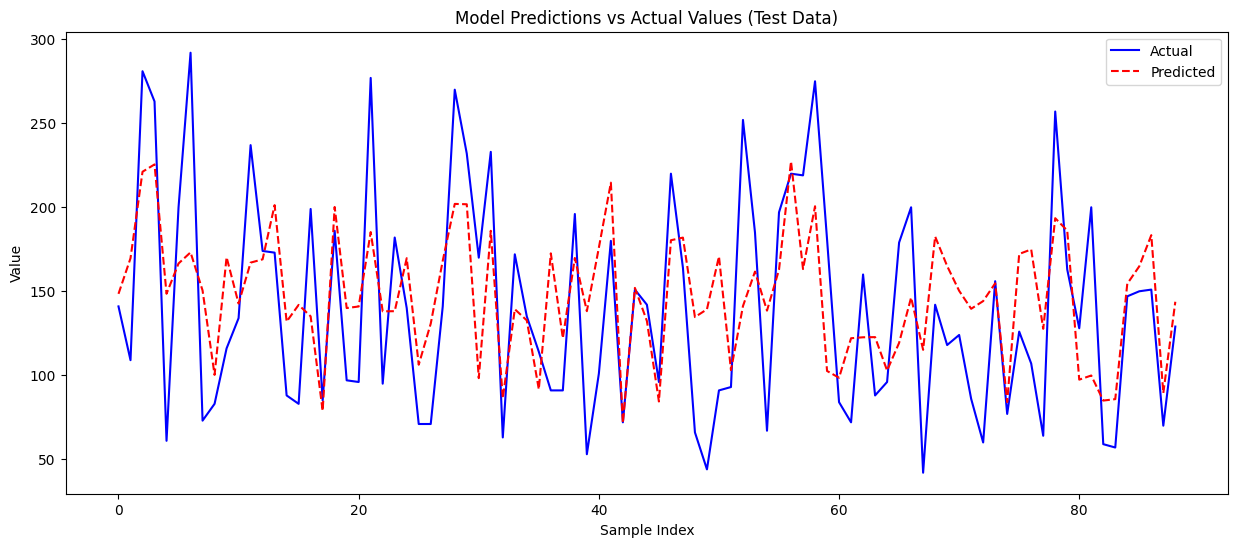

In [226]:
num_samples_to_plot = len(X_real_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_real_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

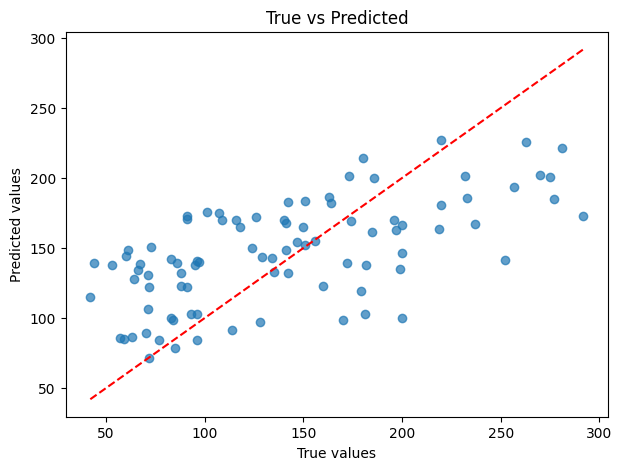

In [227]:
plt.figure(figsize=(7, 5))
plt.scatter(y_real_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_real_test.min(), testPredictions.min())
max_val = max(y_real_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

## Synthetic dataset


In [232]:
X_synt, Y_synt, synth_true_w = generate_synthetic_data(n_samples=200, n_features=20, noise=5.0, seed=42)
X_synt, Y_synt = assingPermuntation(X_synt, Y_synt, seed = 42)
X_synt_train, X_synt_test, y_synt_train, y_synt_test  = trainSplit(X_synt, Y_synt)

# Add bias so we're not completely lost
X_synt_train = add_bias(X_synt_train)
X_synt_test = add_bias(X_synt_test)

# Retrieve ridge weights from a crude implementation
best_synt_w = fitRidge(X_synt_train, X_synt_test, y_synt_train, y_synt_test, epochs = 1000)

# Last test predictions
testPredictions = predict(X_synt_test, best_synt_w)
print(sumError(testPredictions, y_synt_test))



mse_test = mse(y_synt_test, testPredictions)
rmse_test = np.sqrt(mse_test)
print(mse_test, rmse_test)


BEST RESULT:
alpha: 1e-08 lr: 0.001 mse: 22.234696060491917
889.3878424196765
22.234696060491917 4.715368072642041


In [233]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_synt_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_synt_test[i]))

Error for 0: 1.9677304677637735, Prediction: 2.5597290466070666, label : 1.1569708822167204
Error for 1: 59.826879633701466, Prediction: 4.017786634604225, label : 11.752570382951781
Error for 2: 28.932921343234323, Prediction: 1.2846406115754527, label : 6.663573716126422
Error for 3: 104.39226430119353, Prediction: -3.3017249311680814, label : -13.518978197148794
Error for 4: 3.0463024163816828, Prediction: 2.061213527465343, label : 3.806579510971863
Error for 5: 132.3336653183095, Prediction: 0.05997076740391828, label : 11.563607814803731
Error for 6: 12.501559947328573, Prediction: 7.361777293203146, label : 10.897531802120383
Error for 7: 16.73023122038957, Prediction: 0.7878882665501817, label : 4.8781487986421865
Error for 8: 16.93399584006795, Prediction: -1.4540113174377318, label : -5.569104978591503
Error for 9: 0.3630504054621317, Prediction: 0.8253132686625869, label : 0.22277662623979477


### Visualization


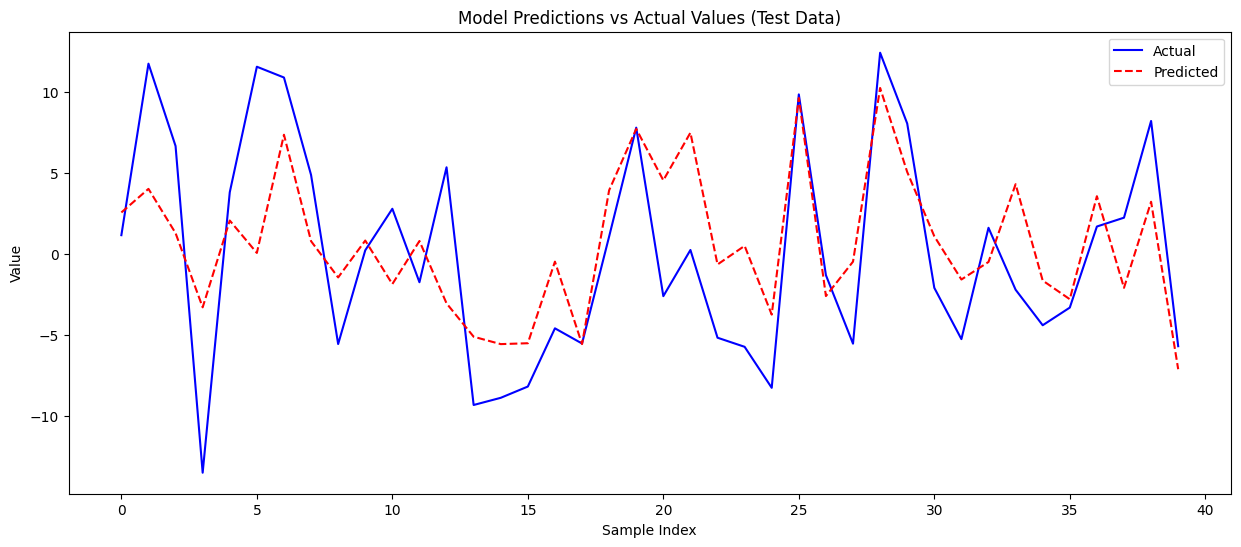

In [234]:
num_samples_to_plot = len(X_synt_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_synt_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

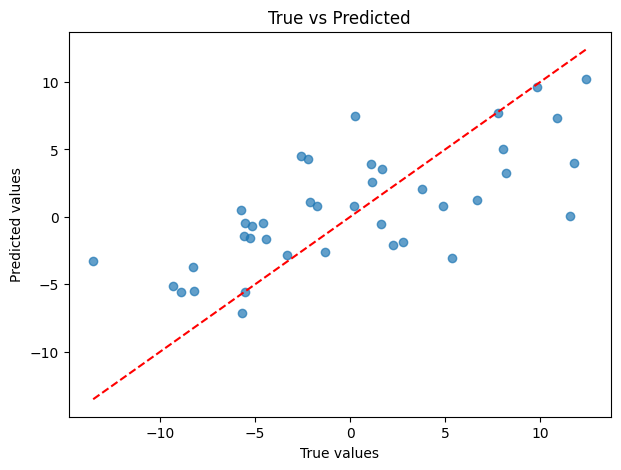

In [235]:
plt.figure(figsize=(7, 5))
plt.scatter(y_synt_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_synt_test.min(), testPredictions.min())
max_val = max(y_synt_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()

# Testing generilization
